In [ ]:
"""
Project: Hierarchical CNN for Breast Cancer Histopathology (BreaKHis)
Author: Salah Eddine Kourradi (SEK171)
Date: April 2026
Description: 40X expert classification model (benign vs malignant)
""";

In [1]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 59.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=5ba805660c1e1cd5a09edf4653ecc20c0fb1695489945ce0bafc72a11b5b3773
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [2]:
import numpy as np

import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms

import cv2
from PIL import Image

import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt
import ast

In [3]:
base_dir = Path("/kaggle/working")
csv_path = "/kaggle/input/notebooks/kourradisalaheddine/master-data-csv/master_dataset.csv"

In [4]:
df = pd.read_csv(csv_path)
df = df[df['magnification'] == '40X'].copy()

In [5]:
df.head(2)

,image_id,file_path,patient_id,tumor_class,tumor_type,magnification,dataset_split
33,SOB_B_A-14-29960CD-40-013.png,/kaggle/input/datasets/ambarish/breakhis/BreaK...,SOB_B_A_14-29960CD,Benign,adenosis,40X,test
34,SOB_B_A-14-29960CD-40-009.png,/kaggle/input/datasets/ambarish/breakhis/BreaK...,SOB_B_A_14-29960CD,Benign,adenosis,40X,test


In [6]:
print(f"Total 40X images: {len(df)}")

Total 40X images: 1995


In [7]:
class_counts = df['tumor_class'].value_counts()

print("--- Dataset Class Distribution ---")
print(class_counts)
print("-" * 32)

--- Dataset Class Distribution ---
tumor_class
Malignant    1370
Benign        625
Name: count, dtype: int64
--------------------------------


In [8]:
LABEL_MAP = {
    'Benign': 0,
    'Malignant': 1
}
CLASSES = ["Benign", "Malignant"]

In [9]:
class ExpertDataset(Dataset):
    def __init__(self, csv_file, transform=None):
        self.data_frame = pd.read_csv(csv_file)
        self.transform = transform

    def __len__(self):
        return len(self.data_frame)

    def __getitem__(self, idx):
        # get the source
        source_text = self.data_frame.iloc[idx]['tumor_class']

        # read the absolute path
        img_path = self.data_frame.iloc[idx]['file_path']
        image = cv2.imread(img_path)
        
        if image is None:
            raise ValueError(f"Could not load image at {img_path}")
            
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = Image.fromarray(image)
        
        label = LABEL_MAP[source_text]

        if self.transform:
            image = self.transform(image)

        return image, label

In [10]:
"""
from tqdm import tqdm

# Temporary for calibrating normalization
calc_transforms = transforms.Compose([
    transforms.Resize((460, 700)),
    transforms.ToTensor() 
])

full_dataset = RouterDataset(csv_file=csv_path, transform=calc_transforms)

stats_loader = DataLoader(
    full_dataset, 
    batch_size=64,    
    shuffle=False,    
    num_workers=2,
    pin_memory=True
)

def calculate_dataset_stats(loader):
    print("Calculating mean and std for BreaKHis...")
    
    channels_sum = torch.tensor([0.0, 0.0, 0.0])
    channels_squared_sum = torch.tensor([0.0, 0.0, 0.0])
    num_batches = 0

    for images, _ in tqdm(loader, desc="Crunching Pixels"):
        channels_sum += torch.mean(images, dim=[0, 2, 3])
        channels_squared_sum += torch.mean(images ** 2, dim=[0, 2, 3])
        num_batches += 1
    
    mean = channels_sum / num_batches
    std = (channels_squared_sum / num_batches - mean ** 2) ** 0.5
    
    return mean, std

mean, std = calculate_dataset_stats(stats_loader)
print(f"\nBreaKHis Mean: {mean.tolist()}")
print(f"BreaKHis Std:  {std.tolist()}")
"""; # commented as to not run by mistake

In [11]:
mean = [0.7867, 0.6264, 0.7641]
std = [0.1299, 0.1801, 0.1150]

In [12]:
# the Augmentation Pipeline for training, obvious names...
train_transforms = transforms.Compose([
    transforms.Resize((460, 700)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=90),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.05, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=mean, 
        std=std) # custom calculated numbers from the dataset
])

# validation goes in raw + normalization
val_transforms = transforms.Compose([
    transforms.Resize((460, 700)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

In [13]:
train_csv_path = base_dir / "expert_40x_train.csv"
val_csv_path = base_dir / "expert_40x_val.csv"

In [14]:
train_df = df[df['dataset_split'] == 'train']
val_df = df[df['dataset_split'] == 'test']

train_df.to_csv(train_csv_path, index=False)
val_df.to_csv(val_csv_path, index=False)

print(f"Total Original Images: {len(df)}")
print(f"Training Images: {len(train_df)}")
print(f"Validation Images: {len(val_df)}")

Total Original Images: 1995
Training Images: 1250
Validation Images: 745


In [15]:
# initialize the datasets
train_dataset = ExpertDataset(csv_file=train_csv_path, transform=train_transforms)
val_dataset = ExpertDataset(csv_file=val_csv_path, transform=val_transforms)

In [16]:
# math for the Weighted Random Sampler

train_df = train_dataset.data_frame

# Order matters: 0: Benign, 1: Malignant
class_counts = [
    len(train_df[train_df['tumor_class'] == 'Benign']),
    len(train_df[train_df['tumor_class'] == 'Malignant'])
]

# calculate the weight for each class (just used the frequency)
class_weights = 1.0 / torch.tensor(class_counts, dtype=torch.float)

# assign weight based on tumor
sample_weights = [class_weights[LABEL_MAP[row['tumor_class']]] for _, row in train_dataset.data_frame.iterrows()]

In [17]:
class_counts

[370, 880]

In [18]:
# create the Sampler for the training data only
sampler = WeightedRandomSampler(
    weights=sample_weights, 
    num_samples=len(sample_weights), # draw all samples each epoch
    replacement=True # allow drawing the same minority image multiple times
)

In [19]:
# create the dataloader for the training data
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    sampler=sampler,
    num_workers=2,
    shuffle=False,
    pin_memory=True
)

In [20]:
# and finally the validation dataloader
val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    num_workers=2,
    shuffle=False,
    pin_memory=True
)

In [21]:
# now for the model

In [22]:
import torch.nn as nn

In [23]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        
        # the conv blocks for feature extraction
        self.features = nn.Sequential(
            
            # first block: 3 channels for RGB (out = (W - K + 2P)/S + 1)
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # slide down the isle babyyy (700x460 -> 350x230)
            
            # second block: 32 -> 64 channels (350x230 -> 175x115)
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # block 3: 64 -> 128 cs (175x115 -> 87x57)
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # block 4: 128 -> 256 cs (87x57 -> 43x28)
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # block 4: 256 -> 512 cs (43x28 -> 21x14)
            # 512 is plenty m8
            nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
            
        )
        
        # squishing time (21x14 -> 1x1) -> tensor shape will be (batch_size, 512, 1, 1)
        self.avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        
        # classifier blocks
        self.classifier = nn.Sequential(
            
            # linear layer with 512 * 1 so... 512... welp
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.5), # dropping 50% just like my will to live
            
            nn.Linear(256, 128), # yknow the drill
            nn.ReLU(),
            nn.Dropout(0.3),
            
            # 2 output options (Benign vs Malignant)
            # we want the pure logits for crossentropy later
            nn.Linear(128, 2)
            
        )
        
        
    def forward(self, x):
        # extract the features
        x = self.features(x)
        
        # pool the space into 1d
        x = self.avg_pool(x)
        
        # flatten the tensor to become a (batch_size, 512) instead of a (batch_size, 512, 1, 1)
        x = torch.flatten(x, 1)
        
        # and finally classify
        x = self.classifier(x)
        
        return x

In [24]:
random_inp = torch.randn(1, 3, 700, 460)
print(random_inp.shape)

test_model = CNN()

output = test_model(random_inp)
print(output)

torch.Size([1, 3, 700, 460])
tensor([[0.0036, 0.2085]], grad_fn=<AddmmBackward0>)


In [25]:
# now for training

In [26]:
import torch.optim as optim

In [27]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [28]:
# initialize the cnn and put it on the gpu
model = CNN().to(device)

In [29]:
optimizer = optim.Adam(model.parameters(), lr=0.001)

# add a schedueler to lower the learning rate after reaching a min
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)

criteria = nn.CrossEntropyLoss()

In [30]:
EPOCHS = 50

In [31]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

In [32]:
best_val_loss = float('inf')

In [33]:
global_epoch = 1

In [34]:
for epoch in range(EPOCHS):
    
    # ==========================================
    # PHASE 1: TRAINING
    # ==========================================
    
    print(f"Starting Training on epoch {epoch + 1}")
    
    # set model to training mode
    model.train()
    
    # initialize metrics
    running_loss = 0.0
    total_predictions = 0
    correct_predictions = 0
        
    # now loop through the batches
    for batch_index, (images, labels) in enumerate(train_loader):
        # gpu transitioning
        images = images.to(device)
        labels = labels.to(device)
        
        # reset the gradients
        optimizer.zero_grad()
        
        # forward pass (damn cnns are nice with it)
        outputs = model(images)
        
        # loss calc
        loss = criteria(outputs, labels)
        
        # and backward pass (i ain't doing this manually again)
        loss.backward()
        
        # and update the weights
        optimizer.step()
        
        # metric update too
        running_loss += loss.item()
        
        # check the prediction
        _, predicted = torch.max(outputs.data, 1)
        total_predictions += labels.size(0)
        correct_predictions += (predicted == labels).sum().item() # the mask of truth
        
        # progress bar
        if (batch_index + 1) % 100 == 0 or (batch_index + 1) == len(train_loader):
            print(f"Epoch [{epoch + 1}/{EPOCHS}] | Batch [{batch_index + 1}/{len(train_loader)}] | Loss: {loss.item():.4f}")
        
    # average
    epoch_train_loss = running_loss / len(train_loader)
    epoch_train_accuracy = (correct_predictions / total_predictions) * 100
    
    # ==========================================
    # PHASE 2: VALIDATION
    # ==========================================
    
    print(f"Starting Validation on epoch {epoch + 1}")
    
    # set to evaluation mode for predicting
    model.eval()
    
    # validation metrics init
    val_running_loss = 0.0
    val_total_predictions = 0
    val_correct_predictions = 0
    
    # no gradient calculations, just predicting
    with torch.no_grad():
        # loop through the validation dataset
        for val_images, val_labels in val_loader:
            # gpu transition
            val_images = val_images.to(device)
            val_labels = val_labels.to(device)
            
            # predict
            val_logits = model(val_images)
            
            # calc and update loss
            val_loss = criteria(val_logits, val_labels)
            val_running_loss += val_loss.item()
            
            # check the predictions
            _, val_predcted = torch.max(val_logits.data, 1)
            val_total_predictions += val_labels.size(0)
            val_correct_predictions += (val_predcted == val_labels).sum().item()
    
    # average
    epoch_val_loss = val_running_loss / len(val_loader)
    epoch_val_accuracy = (val_correct_predictions / val_total_predictions) * 100
    
    
    # display stats
    print("-" * 60)
    print(f"End of Epoch [{epoch + 1}/{EPOCHS}] | Global Epoch: {global_epoch}")
    print(f"TRAIN | Loss: {epoch_train_loss:.4f} | Accuracy: {epoch_train_accuracy:.2f}%")
    print(f"VALID | Loss: {epoch_val_loss:.4f} | Accuracy: {epoch_val_accuracy:.2f}%")
    print("-" * 60)
    
    # check and fix lr
    scheduler.step(epoch_val_loss)
    
    current_lr = scheduler.get_last_lr()[0]
    print(f"Current LR: {current_lr}")
    
    # ==========================================
    # PHASE 3: CHECKPOINT (auto-save)
    # ==========================================
    # check if we fumbled the model
    if epoch_val_loss < best_val_loss:
        print(f"Validation loss decreased ({best_val_loss:.4f} --> {epoch_val_loss:.4f}). Saving model...")
        best_val_loss = epoch_val_loss
        
        # save the model (state_dict) using it's epoch and val loss
        save_path = "/kaggle/working/expert_40x_model.pth"
        
        torch.save(model.state_dict(), save_path)
        
        print(f"Model Updated")
    
    # update the global epoch and teh params
    global_epoch += 1
    
    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    train_accuracies.append(epoch_train_accuracy)
    val_accuracies.append(epoch_val_accuracy)


print("TRAINING COMPLETE")


Starting Training on epoch 1
Epoch [1/50] | Batch [40/40] | Loss: 0.6764
Starting Validation on epoch 1
------------------------------------------------------------
End of Epoch [1/50] | Global Epoch: 1
TRAIN | Loss: 0.5371 | Accuracy: 75.44%
VALID | Loss: 0.8240 | Accuracy: 61.61%
------------------------------------------------------------
Current LR: 0.001
Validation loss decreased (inf --> 0.8240). Saving model...
Model Updated
Starting Training on epoch 2
Epoch [2/50] | Batch [40/40] | Loss: 2.1933
Starting Validation on epoch 2
------------------------------------------------------------
End of Epoch [2/50] | Global Epoch: 2
TRAIN | Loss: 0.5370 | Accuracy: 75.52%
VALID | Loss: 0.5084 | Accuracy: 84.56%
------------------------------------------------------------
Current LR: 0.001
Validation loss decreased (0.8240 --> 0.5084). Saving model...
Model Updated
Starting Training on epoch 3
Epoch [3/50] | Batch [40/40] | Loss: 0.8553
Starting Validation on epoch 3
---------------------

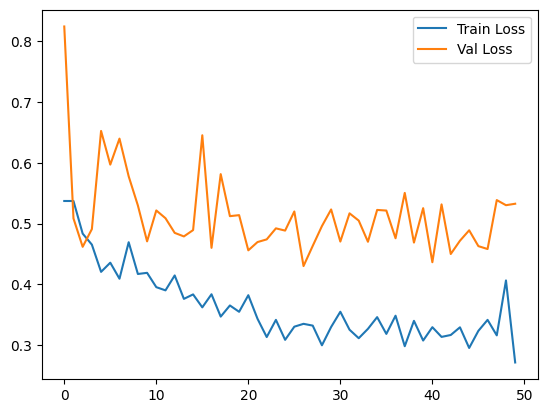

In [35]:
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.legend()

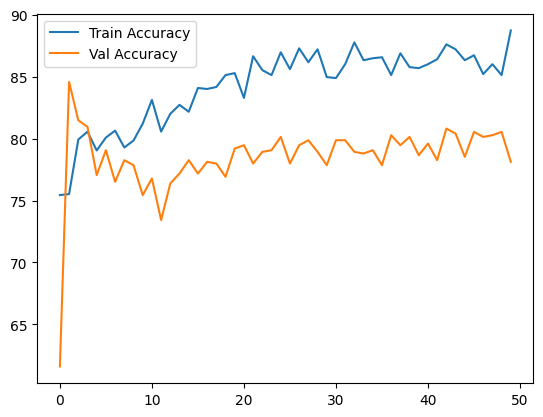

In [36]:
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Val Accuracy')
plt.legend()

In [37]:
# time for some inference

In [38]:
best_model_path = "/kaggle/working/expert_40x_model.pth"

In [39]:
import torch.nn.functional as F
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

In [40]:
inference_transforms = transforms.Compose([
    transforms.Resize((460, 700)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

In [41]:
def predict_and_visualize(image_path, model_path, true_label="Unknown"):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # load the model
    model = CNN().to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()
    
    # load and prep the image
    raw_img_cv2 = cv2.imread(image_path)
    raw_img_rgb = cv2.cvtColor(raw_img_cv2, cv2.COLOR_BGR2RGB)
    
    raw_img_rgb = cv2.resize(raw_img_rgb, (700, 460))
    pil_image = Image.fromarray(raw_img_rgb)
    
    # normalize the raw image strictly to floats between 0 and 1 for the visualizer
    rgb_img_float = np.float32(raw_img_rgb) / 255
    
    # apply transforms for the model
    tensor_image = inference_transforms(pil_image).to(device).unsqueeze(0)
    
    # 1: THE STANDARD PREDICTION
    with torch.no_grad():
        outputs = model(tensor_image)
        _, predicted_idx = torch.max(outputs, 1)
        probabilities = F.softmax(outputs, dim=1)[0]
        confidence = probabilities[predicted_idx.item()] * 100
        
    class_names = ["Benign", "Malignant"]
    diagnosis = class_names[predicted_idx.item()]
    
    all_probs = [f"{class_names[i]}: {probabilities[i]*100:.1f}%" for i in range(2)]
    
    print(f"File: {image_path}")
    print(f"True Label: {true_label}  -->  Predicted: {diagnosis}")
    print(f"Breakdown:  {'  |  '.join(all_probs)}")
    print("-" * 50)

    # 2: GRAD-CAM VISUALIZATION
    # hook the last conv layer
    target_layers = [model.features[-4]]
    
    cam = GradCAM(model=model, target_layers=target_layers)
    
    # trace the gradients
    targets = [ClassifierOutputTarget(predicted_idx.item())]
    
    # generate the raw heatmap
    grayscale_cam = cam(input_tensor=tensor_image, targets=targets)[0, :]
    
    # overlay
    visualization = show_cam_on_image(rgb_img_float, grayscale_cam, use_rgb=True)
    
    # display or save the result
    plt.figure(figsize=(10, 5))
    
    plt.subplot(1, 2, 1)
    plt.imshow(raw_img_rgb)
    plt.title(f"Original Image\nTrue Label: {true_label}")
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(visualization)
    plt.title(f"Grad-CAM (Focus Area)\n{diagnosis}: {confidence:.1f}%")
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

Found 4 images. Firing up the Grad-CAM engine...

File: /kaggle/input/datasets/ambarish/breakhis/BreaKHis_v1/BreaKHis_v1/histology_slides/breast/benign/SOB/phyllodes_tumor/SOB_B_PT_14-21998AB/40X/SOB_B_PT-14-21998AB-40-002.png
True Label: Benign  -->  Predicted: Benign
Breakdown:  Benign: 99.4%  |  Malignant: 0.6%
--------------------------------------------------


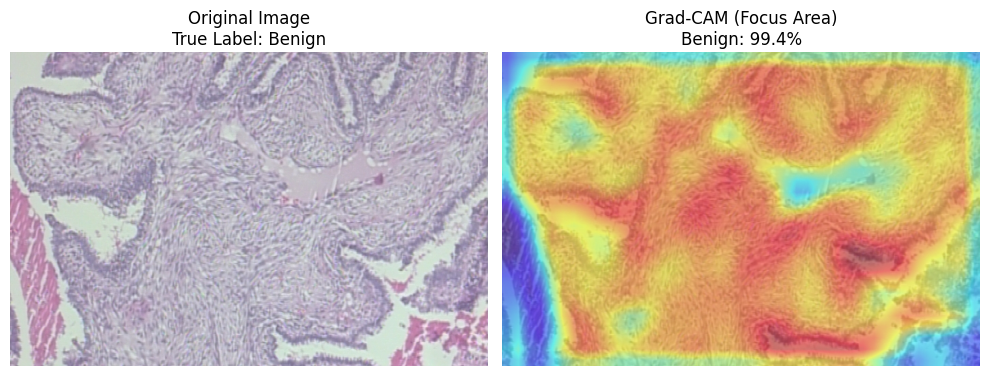

File: /kaggle/input/datasets/ambarish/breakhis/BreaKHis_v1/BreaKHis_v1/histology_slides/breast/benign/SOB/fibroadenoma/SOB_B_F_14-9133/40X/SOB_B_F-14-9133-40-002.png
True Label: Benign  -->  Predicted: Benign
Breakdown:  Benign: 94.9%  |  Malignant: 5.1%
--------------------------------------------------


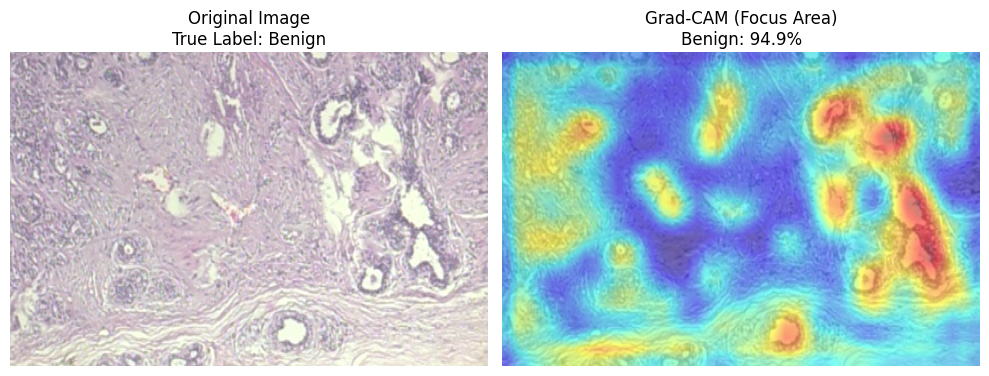

File: /kaggle/input/datasets/ambarish/breakhis/BreaKHis_v1/BreaKHis_v1/histology_slides/breast/malignant/SOB/lobular_carcinoma/SOB_M_LC_14-15570/40X/SOB_M_LC-14-15570-40-014.png
True Label: Malignant  -->  Predicted: Malignant
Breakdown:  Benign: 8.8%  |  Malignant: 91.2%
--------------------------------------------------


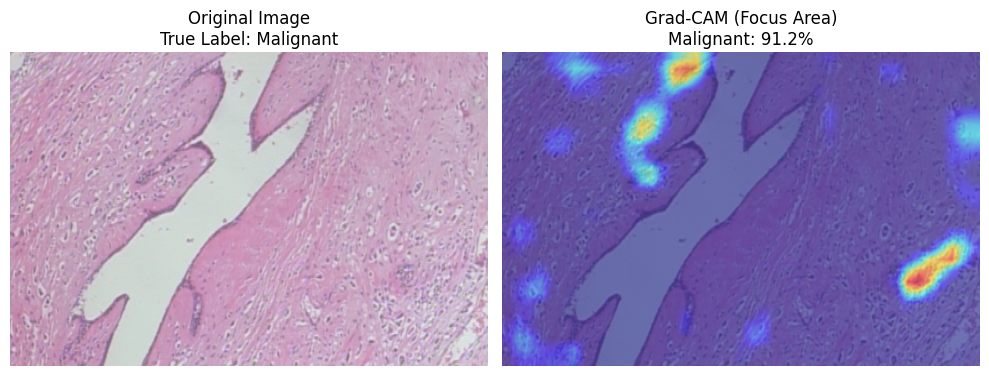

File: /kaggle/input/datasets/ambarish/breakhis/BreaKHis_v1/BreaKHis_v1/histology_slides/breast/malignant/SOB/papillary_carcinoma/SOB_M_PC_14-15704/40X/SOB_M_PC-14-15704-40-002.png
True Label: Malignant  -->  Predicted: Malignant
Breakdown:  Benign: 3.5%  |  Malignant: 96.5%
--------------------------------------------------


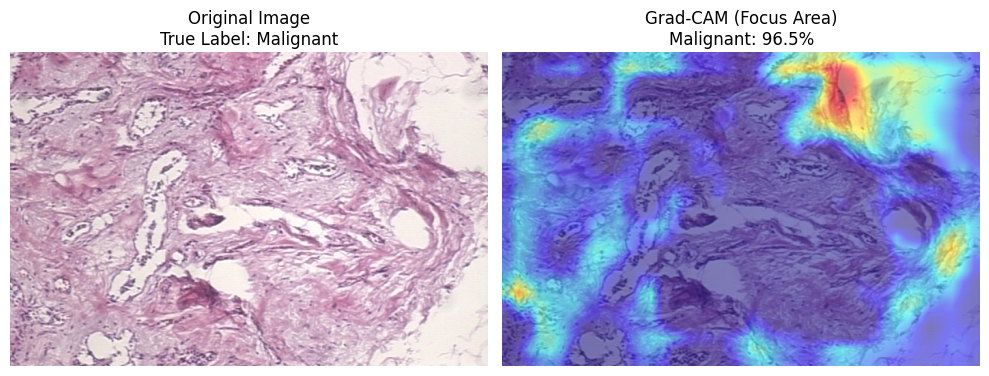

In [42]:
class_names = ["Benign", "Malignant"]
samples_per_class = 2

val_df = val_dataset.data_frame
selected_images_data = []

for class_name in class_names:
    class_subset = val_df[val_df['tumor_class'] == class_name]
    
    # shuffle and pick the images
    sampled_paths = class_subset.sample(n=samples_per_class)['file_path'].tolist()
    
    # save them with their label
    for full_path in sampled_paths:
        selected_images_data.append((full_path, class_name))

print(f"Found {len(selected_images_data)} images. Firing up the Grad-CAM engine...\n")

# run
for full_path, correct_label in selected_images_data:
    predict_and_visualize(full_path, best_model_path, true_label=correct_label)

In [43]:
import seaborn as sns

In [44]:
def generate_confusion_matrix(model_path, val_loader):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # 1. Load
    model = CNN().to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()
    
    # initialize an empty 10x10 matrix using PyTorch
    num_classes = 2
    cm = torch.zeros(num_classes, num_classes, dtype=torch.int32)
    
    print("Evaluating validation dataset...")
    
    # 2. run the entire validation set
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            
            for t, p in zip(labels.view(-1), predicted.view(-1)):
                cm[t.long(), p.long()] += 1
                
    # back to numpy so Seaborn can paint it
    cm_numpy = cm.numpy()
    class_names = ["Benign", "Malignant"]
    
    # 4. paint the Heatmap
    plt.figure(figsize=(10, 8))
    
    sns.heatmap(cm_numpy, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names,
                cbar=False, annot_kws={"size": 10})
    
    plt.title('40X Expert Matrix (Benign vs Malignant)', fontsize=16, pad=20)
    plt.ylabel('Actual Source', fontsize=14, labelpad=10)
    plt.xlabel('Model Prediction', fontsize=14, labelpad=10)
    
    plt.yticks(rotation=0)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

Evaluating validation dataset...


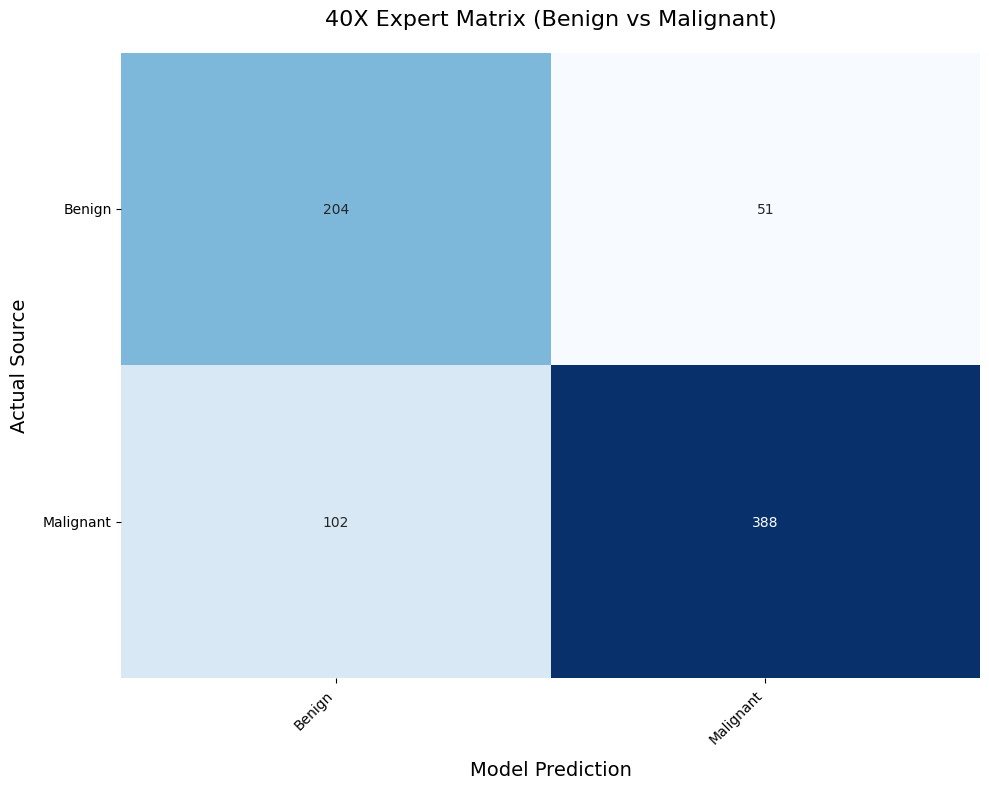

In [45]:
generate_confusion_matrix(best_model_path, val_loader)